### 1. Imports et chemins 

In [1]:
import os, re, csv
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

out_dir = "./output"
data_path = "./data/txt"
os.makedirs(out_dir, exist_ok=True)

print("Dossier sortie :", out_dir)


Dossier sortie : ./output


### 2. Chargement des sorties de s3

In [2]:
p_top_tokens = os.path.join(out_dir, "top_tokens.csv")
p_top_ents   = os.path.join(out_dir, "top_entities.csv")
p_clusters   = os.path.join(out_dir, "clusters.csv")
p_sentiment  = os.path.join(out_dir, "sentiment_sample.csv")

top_tokens  = pd.read_csv(p_top_tokens)       
top_entities = pd.read_csv(p_top_ents)        
clusters    = pd.read_csv(p_clusters)         
sentiment   = pd.read_csv(p_sentiment)       

print(top_tokens.head(3))
print(top_entities.head(3))
print(clusters.head(3))
print(sentiment.head(3))


  token  count
0   ont  12686
1   été  12345
2  mais  11104
        text label  count
0        Roi   PER   1343
1  Bruxelles   LOC    897
2   Belgique   LOC    748
                               file  cluster
0  KB_JB421_1950-01-04_01-00001.txt        3
1  KB_JB421_1950-01-04_01-00002.txt        3
2  KB_JB421_1950-01-04_01-00003.txt        4
                               file label   score
0  KB_JB421_1950-01-04_01-00001.txt   NEU  0.0000
1  KB_JB421_1950-01-04_01-00002.txt   NEU  0.0028
2  KB_JB421_1950-01-04_01-00003.txt   NEU  0.0000


### 3. Top-20 tokens

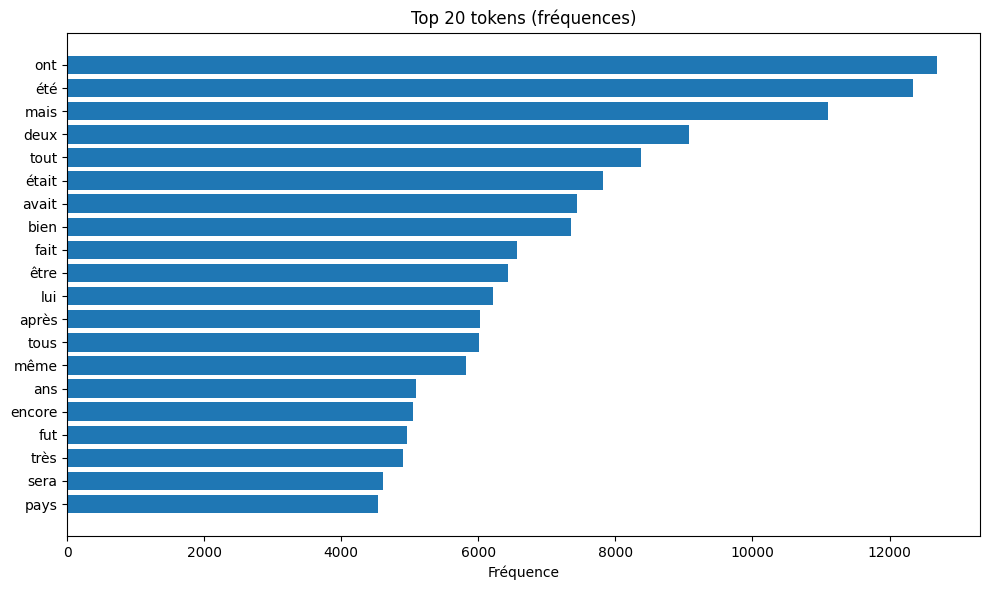

Figure enregistrée : ./output/top20_tokens.png


In [3]:
top20 = top_tokens.sort_values("count", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["token"][::-1], top20["count"][::-1])
plt.title("Top 20 tokens (fréquences)")
plt.xlabel("Fréquence")
plt.tight_layout()

png_path = os.path.join(out_dir, "top20_tokens.png")
plt.savefig(png_path, dpi=150)
plt.show()
print("Figure enregistrée :", png_path)


### 4. Nuage de mots

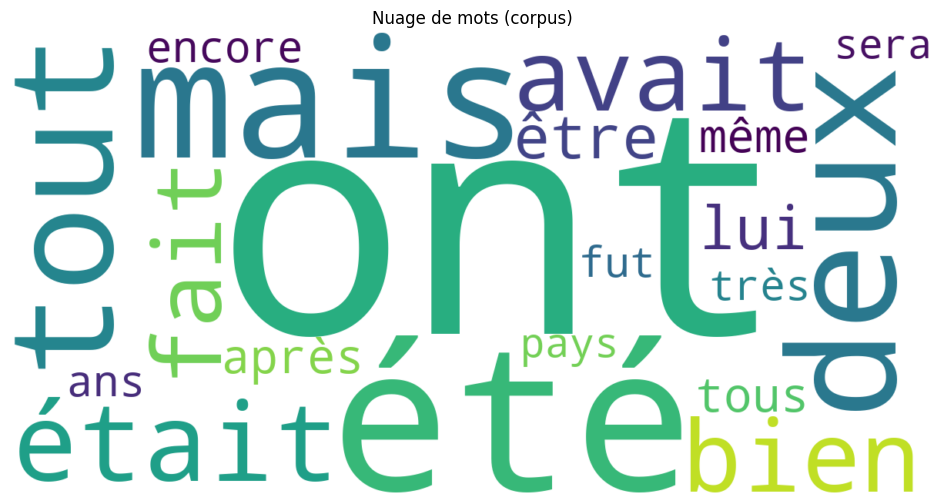

Figure enregistrée : ./output/wordcloud_top.png


In [4]:
try:
    from wordcloud import WordCloud
    freqs = dict(zip(top_tokens["token"], top_tokens["count"]))
    wc = WordCloud(width=1200, height=600, background_color="white").generate_from_frequencies(freqs)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nuage de mots (corpus)")
    png_path = os.path.join(out_dir, "wordcloud_top.png")
    plt.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure enregistrée :", png_path)
except Exception as e:
    print("WordCloud non généré (lib manquante ?):", e)


### 5. Répartition des entités nommées par type

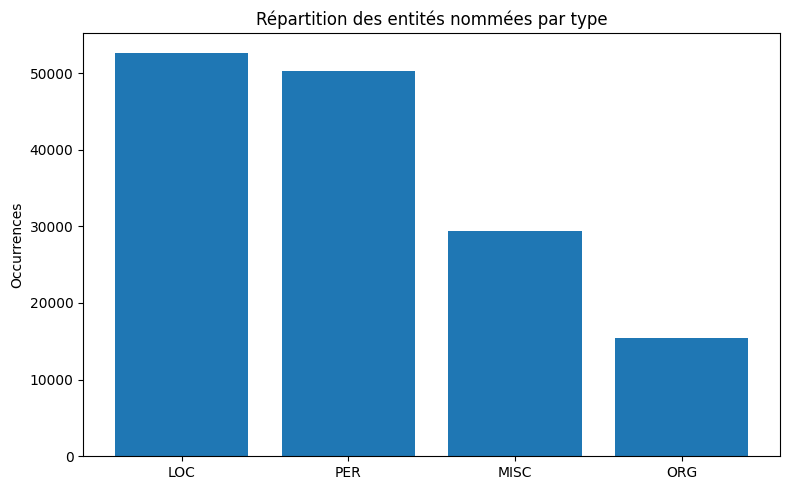

Figure enregistrée : ./output/ner_labels.png


In [5]:
by_label = top_entities.groupby("label")["count"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(by_label.index, by_label.values)
plt.title("Répartition des entités nommées par type")
plt.ylabel("Occurrences")
plt.tight_layout()

png_path = os.path.join(out_dir, "ner_labels.png")
plt.savefig(png_path, dpi=150)
plt.show()
print("Figure enregistrée :", png_path)


### 6. Top entités par label

,text,label,count
0,Roi,PER,1343
1,M.,PER,729
2,H,PER,594
3,A. F. P.,PER,263
4,Athus,PER,257
5,Anne,PER,248
6,Journal Parlé,PER,235
7,Clive,PER,198
8,Horloge,PER,188
9,M. Spaak,PER,172


,text,label,count
0,Bruxelles,LOC,897
1,Belgique,LOC,748
2,Arlon,LOC,733
3,Gouvernement,LOC,505
4,Paris,LOC,456
5,I,LOC,448
6,Etat,LOC,436
7,Liège,LOC,393
8,Londres,LOC,385
9,fr,LOC,379


,text,label,count
0,Conseil,ORG,309
1,U,ORG,205
2,Chambre,ORG,205
3,Parlement,ORG,187
4,Avenir du Luxembourg,ORG,121
5,PAYS,ORG,84
6,Racing,ORG,75
7,ue,ORG,73
8,Standard,ORG,71
9,Commission,ORG,65


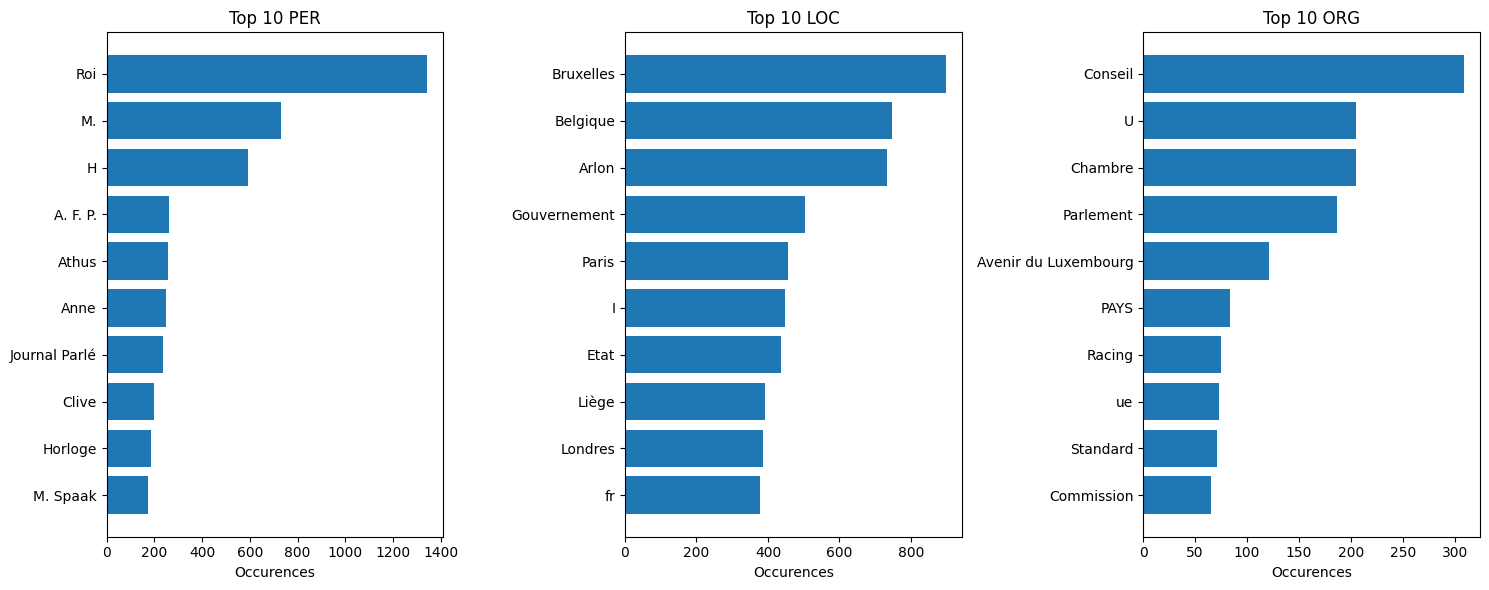

Figure enregistrée : ./output/top_ents_PER_LOC_ORG.png


In [6]:
def top_k_for(label, k=10):
    df = top_entities[top_entities["label"]==label].sort_values("count", ascending=False).head(k)
    return df.reset_index(drop=True)

per10 = top_k_for("PER", 10)
loc10 = top_k_for("LOC", 10)
org10 = top_k_for("ORG", 10)

display(per10)
display(loc10)
display(org10)

fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=False)
for ax, (title, df) in zip(axes, [("PER", per10), ("LOC", loc10), ("ORG", org10)]):
    ax.barh(df["text"][::-1], df["count"][::-1])
    ax.set_title(f"Top 10 {title}")
    ax.set_xlabel("Occurences")
plt.tight_layout()

png_path = os.path.join(out_dir, "top_ents_PER_LOC_ORG.png")
plt.savefig(png_path, dpi=150)
plt.show()
print("Figure enregistrée :", png_path)


### 7. Taille des groupes 

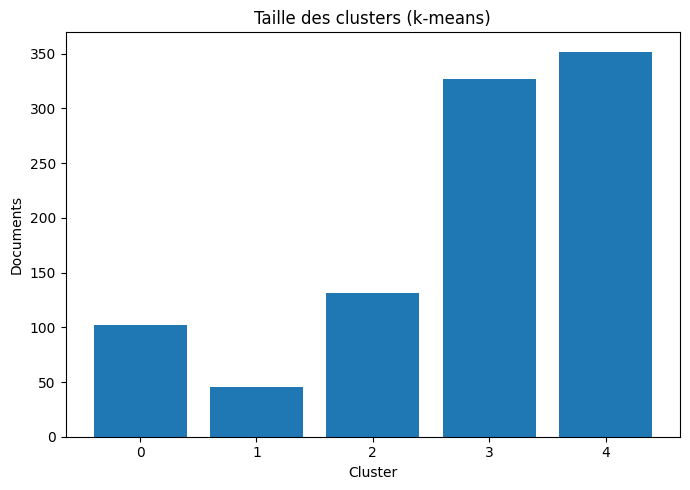

Figure enregistrée : ./output/clusters_sizes.png


,cluster,file
0,0,"[KB_JB421_1950-03-04_01-00004.txt, KB_JB421_19..."
1,1,"[KB_JB421_1950-01-04_01-00004.txt, KB_JB421_19..."
2,2,"[KB_JB421_1950-01-05_01-00005.txt, KB_JB421_19..."
3,3,"[KB_JB421_1950-01-04_01-00001.txt, KB_JB421_19..."
4,4,"[KB_JB421_1950-01-04_01-00003.txt, KB_JB421_19..."


In [7]:
sizes = clusters["cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(sizes.index.astype(str), sizes.values)
plt.title("Taille des clusters (k-means)")
plt.xlabel("Cluster")
plt.ylabel("Documents")
plt.tight_layout()

png_path = os.path.join(out_dir, "clusters_sizes.png")
plt.savefig(png_path, dpi=150)
plt.show()
print("Figure enregistrée :", png_path)

preview = clusters.groupby("cluster")["file"].apply(lambda s: list(s.head(5))).reset_index()
preview


### 8. Sentiment (échantillon)

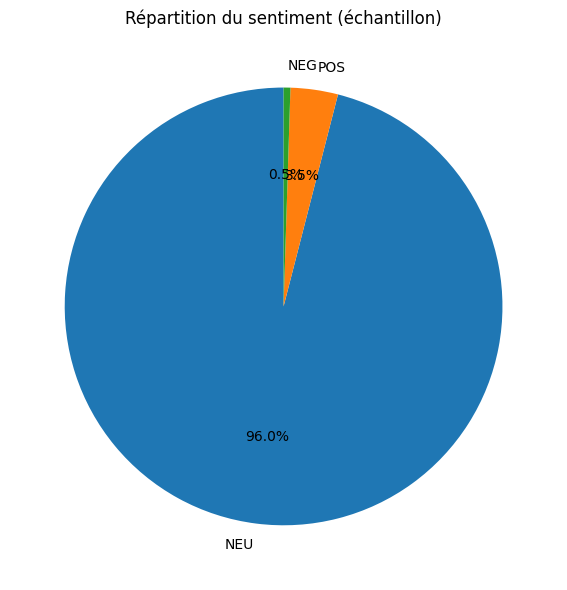

Figure enregistrée : ./output/sentiment_pie.png


In [8]:
counts = sentiment["label"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Répartition du sentiment (échantillon)")
plt.tight_layout()

png_path = os.path.join(out_dir, "sentiment_pie.png")
plt.savefig(png_path, dpi=150)
plt.show()
print("Figure enregistrée :", png_path)


### 9. Courbe temporelle d’un terme

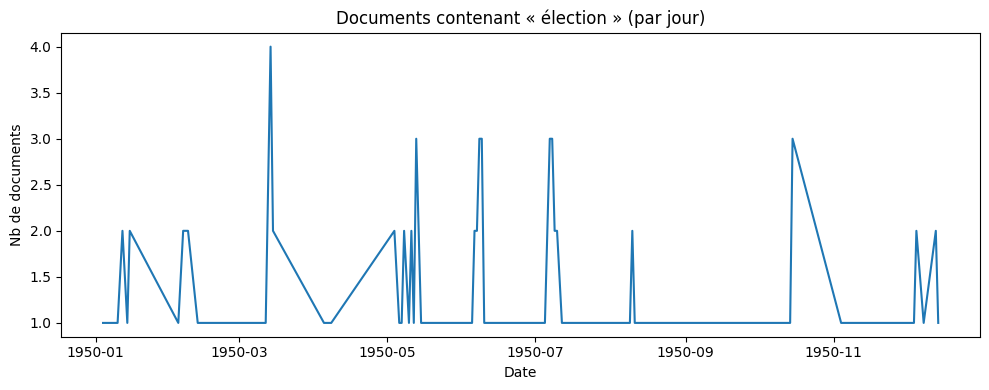

Figure enregistrée : ./output/timeseries_élection.png


In [9]:
import datetime as dt

token_re = re.compile(r"[a-zàâçéèêëîïôûùüÿœæ-]{3,}", re.IGNORECASE)
STOP = set()  
def tokenize(txt:str):
    toks = [t.lower() for t in token_re.findall(txt)]
    return [t for t in toks if t not in STOP]

term = "élection"  

def extract_date_from_filename(name:str):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", name)
    if m:
        return dt.date.fromisoformat(m.group(1))
    return None

counts_by_day = Counter()

for fname in sorted(os.listdir(data_path)):
    if not fname.endswith(".txt"): 
        continue
    fpath = os.path.join(data_path, fname)
    with open(fpath, encoding="utf-8", errors="replace") as fh:
        txt = fh.read()
    toks = set(tokenize(txt))
    d = extract_date_from_filename(fname)
    if d and term in toks:
        counts_by_day[d] += 1

if counts_by_day:
    dates = sorted(counts_by_day)
    vals  = [counts_by_day[d] for d in dates]

    plt.figure(figsize=(10,4))
    plt.plot(dates, vals)
    plt.title(f"Documents contenant « {term} » (par jour)")
    plt.xlabel("Date")
    plt.ylabel("Nb de documents")
    plt.tight_layout()

    png_path = os.path.join(out_dir, f"timeseries_{term}.png")
    plt.savefig(png_path, dpi=150)
    plt.show()
    print("Figure enregistrée :", png_path)
else:
    print(f"Aucune occurrence trouvée pour le terme « {term} »")


### 10. Récapitulatif des fichiers

In [10]:
for fn in sorted(os.listdir(out_dir)):
    if fn.lower().endswith(".png"):
        print("✔", os.path.join(out_dir, fn))


✔ ./output/clusters_sizes.png
✔ ./output/ner_labels.png
✔ ./output/sentiment_pie.png
✔ ./output/timeseries_élection.png
✔ ./output/top20_tokens.png
✔ ./output/top_ents_PER_LOC_ORG.png
✔ ./output/wordcloud_top.png
